# scSVC-reconstructed CAFs uncovers their functionally distinct niches within the tumor microenvironment

## Notebook Guide

**Purpose.** Analyze CAF/Fibroblast sc-SVC states, pathway programs, spatial niches, and pseudotime-like transitions.

**Inputs.** Executed Fibroblast reconstruction outputs under `../../output/sc_SVC_case/P2CRC_Xenium/Fibroblast/` plus raw Xenium data.

**Outputs.** CAF subtype maps, marker plots, enrichment/pathway figures, spatial niche plots, and trajectory visualizations displayed inline and saved to disk.

**Reading order.**
1. Load reconstructed SVCs
2. Annotate CAF subtypes and marker programs
3. Summarize pathway enrichments
4. Compare spatial niches and trajectory structure

**Reproducibility note.** `revise` imports are standard package imports from the installed `revise-svc` distribution; this notebook does not modify `sys.path` to import the repository source tree.


In [1]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

output_dir = "../../output/sc_SVC_case/P2CRC_Xenium"
select_ct = "Fibroblast"


## Load Reconstructed SVCs

Load the executed reconstruction outputs that drive the downstream figures.


In [2]:
import os
import scanpy as sc

from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
try:
    import gseapy as gp
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install pathway dependencies with pip install \"revise-svc[pathway]\"') from exc
import revise.analysis.bio as _revise_bio

_EMPTY_ENRICHMENT_COLUMNS = [
    "Gene_set",
    "Term",
    "Overlap",
    "P-value",
    "Adjusted P-value",
    "Old P-value",
    "Old Adjusted P-value",
    "Odds Ratio",
    "Combined Score",
    "Genes",
]

def _get_enrichment_human_compatible(deg_genes, geneset_file, cutoff=0.05):
    if not deg_genes:
        return pd.DataFrame(columns=_EMPTY_ENRICHMENT_COLUMNS)
    try:
        enr = gp.enrichr(
            gene_list=deg_genes,
            gene_sets=geneset_file,
            organism="human",
            cutoff=cutoff,
        )
        return enr.results
    except Exception as exc:
        print(f"Skipping enrichment analysis: {type(exc).__name__}: {exc}")
        return pd.DataFrame(columns=_EMPTY_ENRICHMENT_COLUMNS)

_revise_bio.get_enrichment = _get_enrichment_human_compatible


svc_save_dir = f"{output_dir}/{select_ct}"
sc_svc_expr = sc.read_h5ad(f"{svc_save_dir}/sc_SVC_expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{svc_save_dir}/sc_SVC_spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr, 
                            "SVC_cluster")
# Rebuild the upstream variables that the legacy analysis notebook expected
# from the reconstruction notebook kernel state.
patient_id = "P2CRC"
data_type = "Xenium"
raw_data_path = "../../raw_data/Real_application"
raw_file_name = f"{raw_data_path}/{patient_id}_{data_type}.h5ad"
sc_ref_file = f"{raw_data_path}/adata_sc_all_reanno.h5ad"

adata_sp = sc.read(raw_file_name)
adata_sp = adata_sp[adata_sp.obs['transcript_counts'] >= 60, :].copy()
sc.pp.filter_genes(adata_sp, min_cells=100)

adata_sc = sc.read(sc_ref_file)
adata_sc = adata_sc[adata_sc.obs['Patient'] == patient_id, :].copy()
adata_sc.obs = adata_sc.obs[['Level1', 'Level2']]
sc.pp.filter_genes(adata_sc, min_cells=100)
adata_sc.obs['Level1'].replace({"Mono/Macro": "Mono_Macro"}, inplace=True)

overlap_genes = adata_sp.var_names.intersection(adata_sc.var_names)
adata_sp = adata_sp[:, overlap_genes].copy()

sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()


def _apply_category_palette(adata, key, palette, fallback="#d3d3d3"):
    """Keep categorical colors aligned with the categories present in the plotted subset."""
    if key not in adata.obs:
        return
    if not hasattr(adata.obs[key], "cat"):
        adata.obs[key] = adata.obs[key].astype("category")
    adata.obs[key] = adata.obs[key].cat.remove_unused_categories()
    categories = adata.obs[key].cat.categories.astype(str).tolist()
    adata.uns[f"{key}_colors"] = [palette.get(category, fallback) for category in categories]


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Conducting differential expression analysis...


/tmp/ipykernel_30433/566921725.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata_sc.obs['Level1'].replace({"Mono/Macro": "Mono_Macro"}, inplace=True)
/tmp/ipykernel_30433/566921725.py:62: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sc.obs['Level1'].replace({"Mono/Macro": "Mono_Macro"}, inplace=True)

In [3]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/runners/sc_svc_application.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = self.sc_SVC_adata_expr.obs.groupby([self.cluster_col, sub_cell_type_col]).size()


Level2,apCAF,iCAF,mCAF,pCAF
SVC_cluster,,,,
0,105,30,135,4
1,14,25,305,1
2,15,120,5,0
3,44,120,252,1
4,27,10,146,5
5,65,48,243,6
6,37,48,20,0
7,32,2,6,1
8,7,4,94,5


/tmp/ipykernel_30433/351559165.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', lut=10)


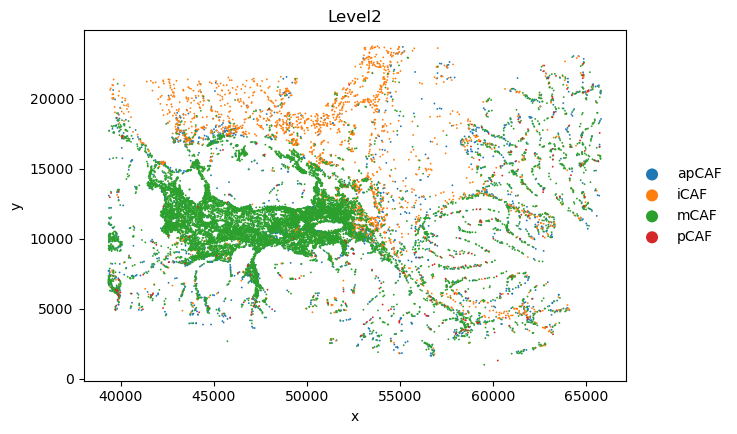

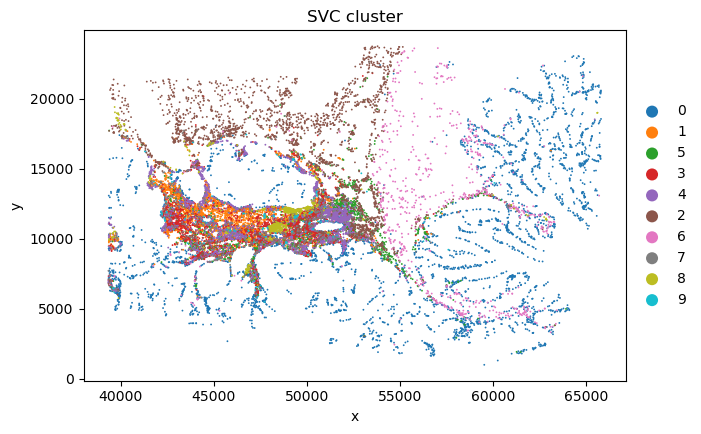

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['0', '1', '5', '3', '4', '2', '6', '7', '8', '9']  # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Spatial Subtype Maps

Display reconstructed spatial cell states and side-by-side annotation comparisons.


<Figure size 1000x800 with 0 Axes>

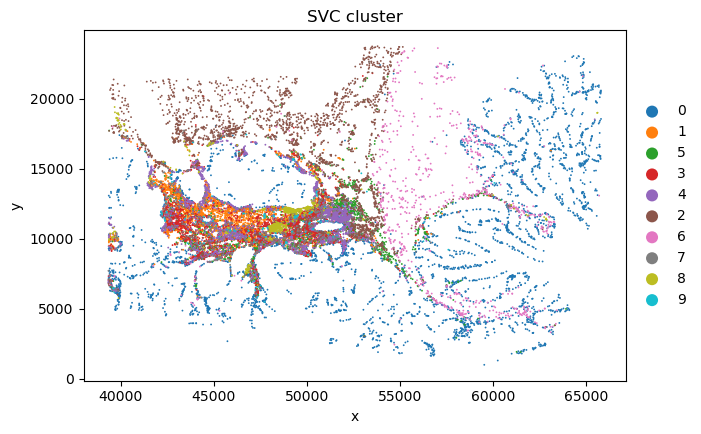

<Figure size 1000x1600 with 0 Axes>

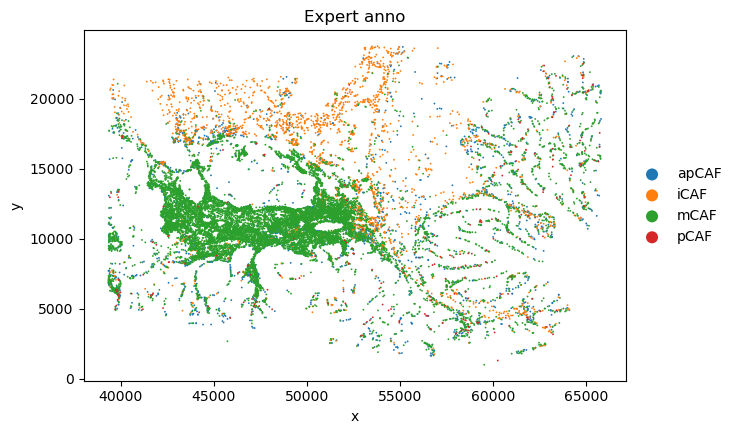

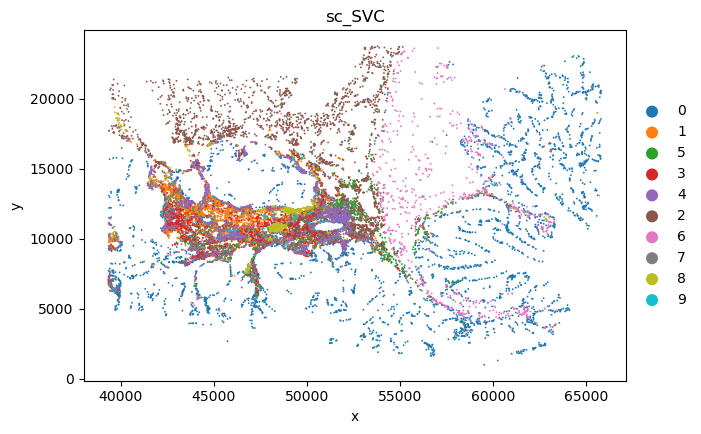

In [5]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## Marker gene analysis

In [6]:
sc_svc_analysis.sc_SVC_degs.to_csv(f"{output_dir}/degs_all.csv")
sc_svc_analysis.sc_SVC_degs

,group,gene,logfoldchanges,pvals,pvals_adj,log_q
0,3,C3,4.284732,2.006549e-242,2.626171e-238,100.000000
1,1,TIMP3,3.870138,8.797006e-79,1.151352e-74,73.938792
2,5,TAGLN,3.033704,1.085613e-76,1.420850e-72,71.847452
3,1,COMP,5.330997,4.945397e-76,3.236268e-72,71.489956
4,2,INHBA,-4.796747,7.599509e-71,9.946238e-67,66.002341
...,...,...,...,...,...,...
130875,8,C4BPB,0.000000,1.000000e+00,1.000000e+00,-0.000000
130876,8,IL26,0.000000,1.000000e+00,1.000000e+00,-0.000000
130877,8,TM4SF20,0.000000,1.000000e+00,1.000000e+00,-0.000000
130878,8,NOS3,0.000000,1.000000e+00,1.000000e+00,-0.000000


## Marker And Differential Programs

Summarize marker genes, differential genes, and pathway-level signals.


Conducting differential expression analysis...


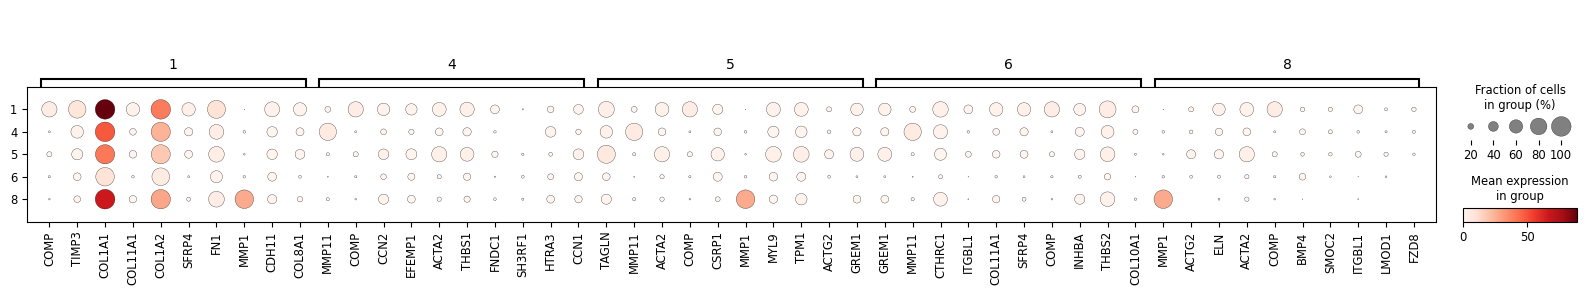

In [7]:
cluster_nums = ['1', '4', '5', '6', '8']

degs = sc_svc_analysis.get_svc_degs(cluster_nums)
marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(10).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict)

In [8]:
for i,j in marker_dict.items():
    print(i, j)

1 ['COMP', 'TIMP3', 'COL1A1', 'COL11A1', 'COL1A2', 'SFRP4', 'FN1', 'MMP1', 'CDH11', 'COL8A1']
4 ['MMP11', 'COMP', 'CCN2', 'EFEMP1', 'ACTA2', 'THBS1', 'FNDC1', 'SH3RF1', 'HTRA3', 'CCN1']
5 ['TAGLN', 'MMP11', 'ACTA2', 'COMP', 'CSRP1', 'MMP1', 'MYL9', 'TPM1', 'ACTG2', 'GREM1']
6 ['GREM1', 'MMP11', 'CTHRC1', 'ITGBL1', 'COL11A1', 'SFRP4', 'COMP', 'INHBA', 'THBS2', 'COL10A1']
8 ['MMP1', 'ACTG2', 'ELN', 'ACTA2', 'COMP', 'BMP4', 'SMOC2', 'ITGBL1', 'LMOD1', 'FZD8']


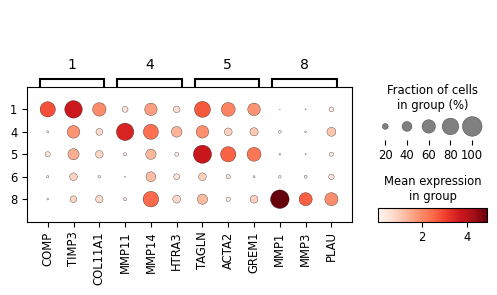

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False

marker_dict = {
    "1": ['COMP', 'TIMP3', 'COL11A1'], # ECM-Architect	
    "4": ['MMP11',  # Inflamed-Proteolytic
          'MMP14', 'HTRA3'],
    "5": ['TAGLN', 'ACTA2', 'GREM1', #  SMC-like CAF	
          ],
    "8": ['MMP1', 'MMP3', 'PLAU', # ECM-Destructive	desCAF	
          ]
    }

sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)

<Figure size 800x600 with 0 Axes>

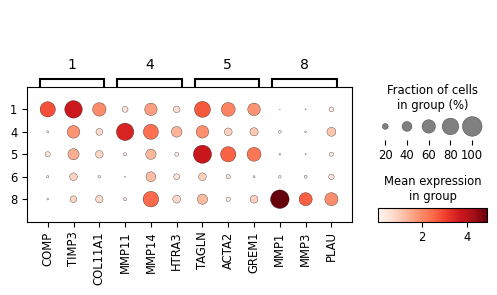

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(8, 6))
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## sc_SVC subclusters bioinformatical analysis

In [11]:
cluster_nums

['1', '4', '5', '6', '8']

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


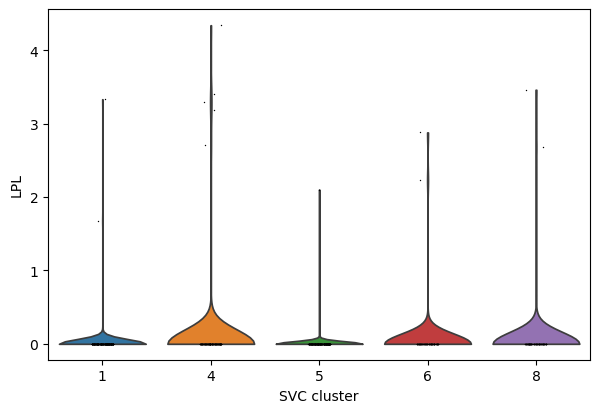

In [12]:
sc_svc_analysis.get_violin_plot(cluster_nums, True)

In [13]:
fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = ["MSigDB_Hallmark_2020", "KEGG_2021_Human", "GO_Biological_Process_2025"]
# geneset_file = ["MSigDB_Hallmark_2020"]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=True)
all_pathway.to_csv(pathway_file_name)

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Conducting differential expression analysis...


Cluster 1: 
Up-regulated genes: ['COMP', 'TIMP3', 'COL1A1', 'COL11A1', 'COL1A2', 'SFRP4', 'FN1', 'CDH11', 'COL8A1', 'SFRP2', 'THBS2', 'IGFBP3', 'COL5A1', 'ELN', 'SPARC', 'C3', 'ITGBL1', 'SERPINE2', 'CTHRC1', 'PRSS23', 'BGN', 'CDKN2B', 'ISLR', 'COL6A3', 'FNDC1', 'PLXDC2', 'COL10A1', 'FBLN2', 'MFAP5', 'VCAN', 'AEBP1', 'ITGA11', 'ADAM12', 'LOXL1', 'SEMA3C', 'COL16A1', 'C1QTNF3', 'MATN3', 'THBS1', 'LRP1', 'SPON1', 'CCN2', 'PRELP', 'SLC44A1', 'TIMP1', 'CD248', 'CKAP4', 'ENC1', 'COL15A1', 'EFEMP1', 'SLC12A8', 'PPIC', 'ANOS1', 'SDC2', 'ASPN', 'MGP', 'LAMP5', 'HSPG2', 'TSPAN2', 'FZD8']
Enriched pathways: ['Epithelial Mesenchymal Transition' 'Protein digestion and absorption'
 'ECM-receptor interaction' 'Coagulation'
 'Extracellular Matrix Organization (GO:0030198)'
 'Proteoglycans in cancer' 'Focal adhesion'
 'External Encapsulating Structure Organization (GO:0045229)'
 'Extracellular Structure Organization (GO:0043062)'
 'Skeletal System Development (GO:0001501)' 'Malaria'
 'Human papillomavi

Cluster 4: 
Up-regulated genes: ['MMP11', 'HTRA3', 'MMP14', 'DKK3', 'ANTXR1', 'IGFBP7', 'B2M', 'GRN', 'CTSB', 'CXCL14', 'PLAT', 'ISLR', 'NID1', 'ECM1', 'BST2', 'PLAU', 'ST5', 'ITIH5', 'PDPN', 'A2M', 'PCDH18', 'PAG1', 'F3', 'BMP8A', 'FXYD6', 'OPTN', 'GPC1', 'TCF4', 'F2R', 'ARL4C', 'CPXM1', 'ABCC4', 'COCH', 'LSP1', 'NSG1', 'PSMB8', 'WNT5A', 'APCDD1', 'COL7A1', 'ALCAM', 'PLXDC1', 'TNFRSF21', 'IFI30', 'AGT', 'PTPRS', 'OLFML2A', 'FOXF1', 'TMEM158', 'WNT4', 'SLC16A1', 'NUDT2', 'NOTCH3', 'TM4SF1', 'FOXQ1', 'CD82', 'PCF11', 'TSR3', 'RIN2', 'ETS1', 'NDNF']
Enriched pathways: ['Coagulation' 'Positive Regulation of Blood Coagulation (GO:0030194)'
 'Positive Regulation of Cell Migration (GO:0030335)' 'KRAS Signaling Up'
 'Complement and coagulation cascades' 'Interferon Alpha Response'
 'Epithelial Mesenchymal Transition' 'IL-2/STAT5 Signaling'
 'Inflammatory Response'
 'Positive Regulation of Response to External Stimulus (GO:0032103)'
 'Positive Regulation of Vasculature Development (GO:1904018)

Cluster 8: 
Up-regulated genes: ['MMP1', 'MMP3', 'PLAU', 'CHI3L1', 'CXCL5', 'FAM20C', 'COL6A1', 'IL7R', 'SOD2', 'COL3A1', 'APOE', 'CXCL1', 'POSTN', 'PCOLCE', 'MMP14', 'FTH1', 'PDPN', 'PRRX1', 'C3', 'CTSK', 'CXCL6', 'FBLN2', 'MME', 'MMP9', 'COL7A1', 'STEAP1', 'FAP', 'RIPOR3', 'TDO2', 'ADAMTS2', 'CEBPB', 'CA12', 'SAT1', 'PLK2', 'EPAS1', 'TSPAN11', 'SULF2', 'MXRA5', 'SDK1', 'SPHK1', 'BMP1', 'ADRA2A', 'CD82', 'DIO2', 'ANGPTL2', 'NOTCH3', 'ITGA5', 'RARRES2', 'CCDC71L', 'ICAM1', 'LAPTM4B', 'CYP7B1', 'PTPRU', 'WNT5A', 'SLC16A3', 'CHST15', 'COL5A3', 'ADM', 'MT2A', 'RNF144A']
Enriched pathways: ['Epithelial Mesenchymal Transition'
 'Extracellular Matrix Organization (GO:0030198)'
 'TNF-alpha Signaling via NF-kB'
 'External Encapsulating Structure Organization (GO:0045229)'
 'Extracellular Structure Organization (GO:0043062)' 'Coagulation'
 'Inflammatory Response' 'TNF signaling pathway' 'IL-17 signaling pathway'
 'Rheumatoid arthritis' 'Collagen Catabolic Process (GO:0030574)'
 'Endodermal Cell

Cluster 5: 
Up-regulated genes: ['TAGLN', 'ACTA2', 'CSRP1', 'MYL9', 'TPM1', 'ACTG2', 'GREM1', 'MYLK', 'MYH11', 'DES', 'TPM2', 'THBS1', 'CNN1', 'CALD1', 'HSPB1', 'SORBS1', 'FLNA', 'CRYAB', 'LPP', 'MYL6', 'PPP1R12B', 'CCN1', 'SYNPO2', 'FLNC', 'TGFBR1', 'ALKAL1', 'MAP4', 'PLN', 'LBH', 'MGP', 'ENAH', 'CLU', 'MCAM', 'LIMA1', 'MYH10', 'PALLD', 'FERMT2', 'SH3PXD2A', 'ID4', 'DBNL', 'SLMAP', 'CDH2', 'LMOD1', 'PNN', 'LIMS2', 'ACAN', 'GLIPR1', 'NR4A1', 'PEF1', 'PRUNE2', 'PHLDB2', 'BEX3', 'PTGER3', 'KIF5B', 'BTAF1', 'NEXN', 'NR2F2', 'MAP1B', 'PPP1R12A', 'MICAL3']
Enriched pathways: ['Epithelial Mesenchymal Transition' 'Vascular smooth muscle contraction'
 'Muscle Contraction (GO:0006936)'
 'Actomyosin Structure Organization (GO:0031032)' 'Myogenesis'
 'Supramolecular Fiber Organization (GO:0097435)'
 'Myofibril Assembly (GO:0030239)' 'Focal adhesion'
 'Regulation of actin cytoskeleton' 'Apical Junction'
 'Regulation of Muscle Contraction (GO:0006937)'
 'Regulation of Muscle System Process (GO:0090

Cluster 6: 
Up-regulated genes: ['APOE', 'ADAMDEC1', 'A2M', 'FOS', 'PIGR', 'PTGDS', 'NR4A1', 'MUC12', 'CFD', 'ADAM28', 'FOSB', 'ARGLU1', 'CEACAM5', 'CXCL12', 'IGKC', 'MAMDC2', 'PLPP3', 'LCN2', 'ADGRL2', 'SCARA5', 'PDGFRA', 'TFPI2', 'TCF21', 'SELENOP', 'NRG1', 'JUP', 'CXCL1', 'TCIM', 'PNISR', 'ZFP36L1', 'LTBP4', 'EDNRB', 'SMPDL3A', 'EGR1', 'PITPNC1', 'IGHG3', 'CXCL2', 'JUND', 'CHI3L1', 'CMIP', 'BTG1', 'DDX5', 'ADAMTS1', 'LENG8', 'ADH1B', 'MAPK10', 'PHLDA1', 'KSR1', 'SYNGR2', 'C11orf96', 'ZFP36', 'COL4A5', 'DLL1', 'NFKBIA', 'IGHG1', 'FGF7', 'P2RY14', 'NID1', 'PTGER4', 'GPCPD1']
Enriched pathways: ['TNF-alpha Signaling via NF-kB' 'IL-17 signaling pathway'
 'Pathways in cancer' 'UV Response Up' 'Choline metabolism in cancer'
 'Kaposi sarcoma-associated herpesvirus infection' 'TNF signaling pathway'
 'Relaxin signaling pathway' 'Osteoclast differentiation'
 'Epithelial cell signaling in Helicobacter pylori infection'
 'Rheumatoid arthritis' 'Th1 and Th2 cell differentiation'
 'MAPK signalin

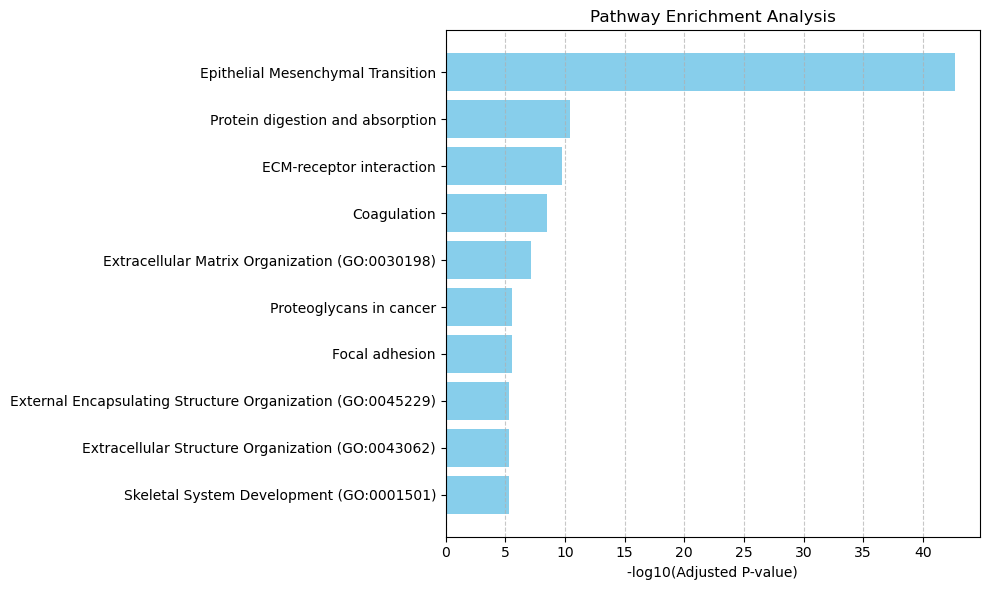

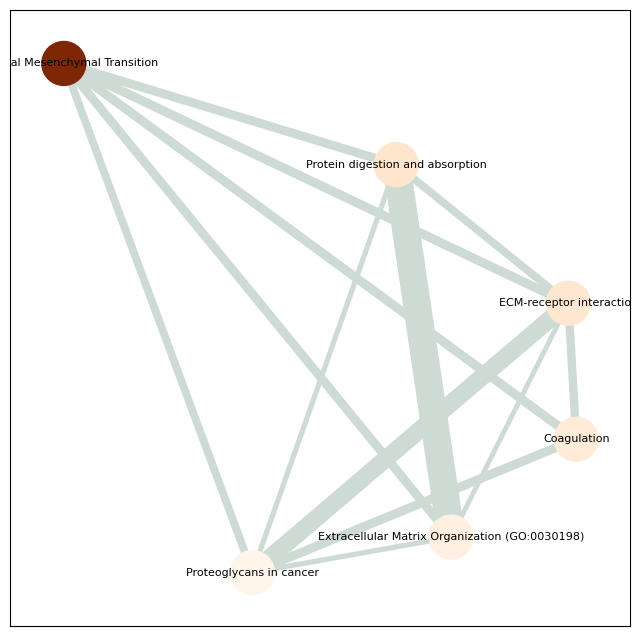

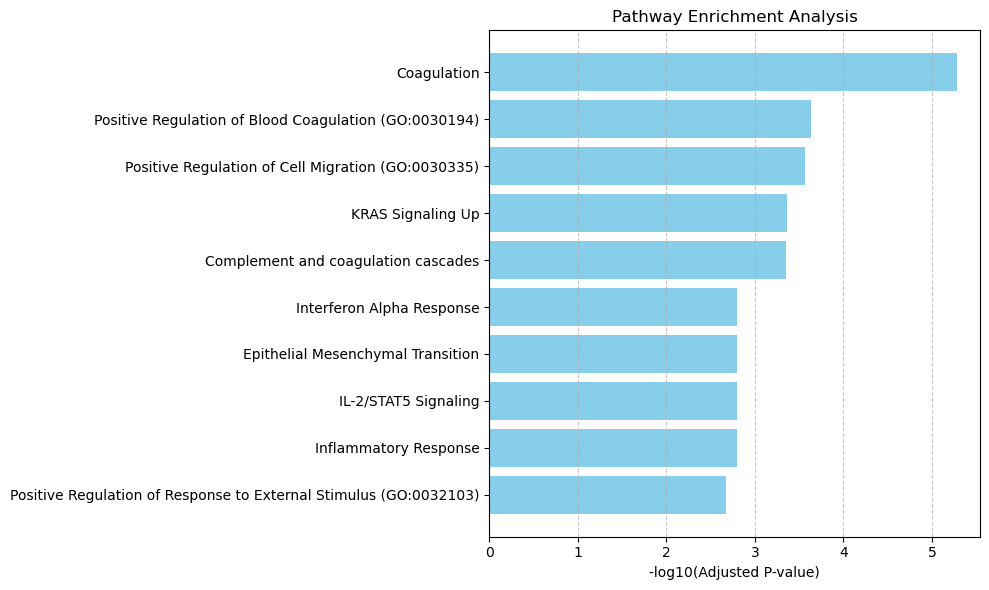

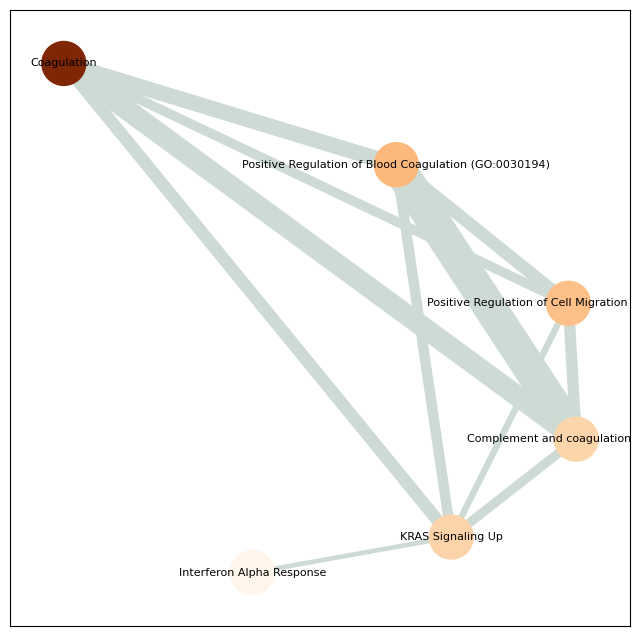

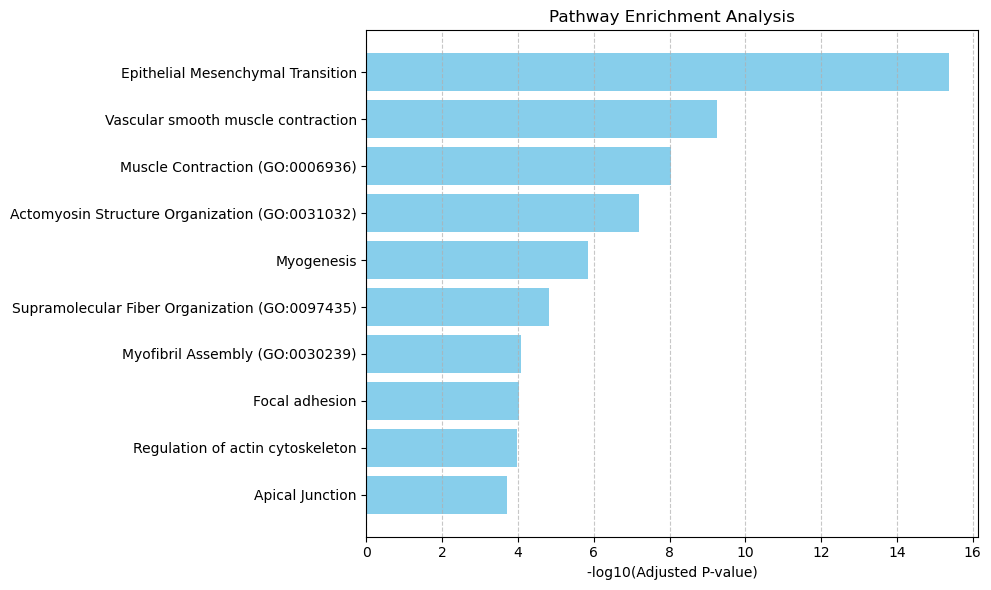

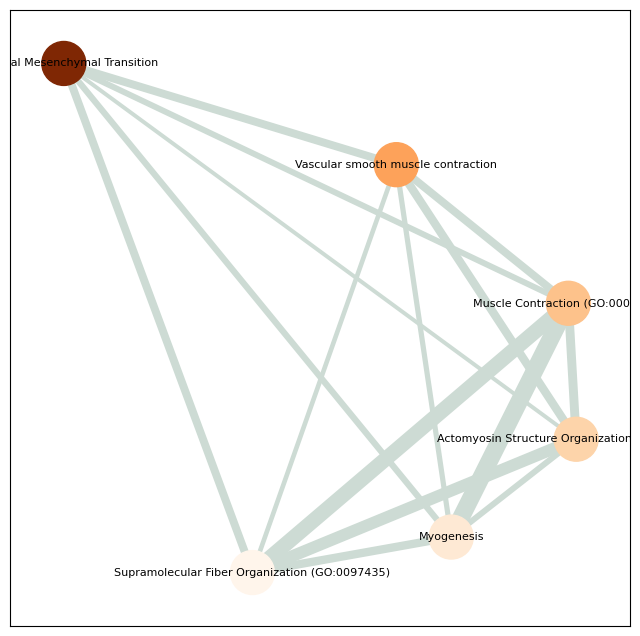

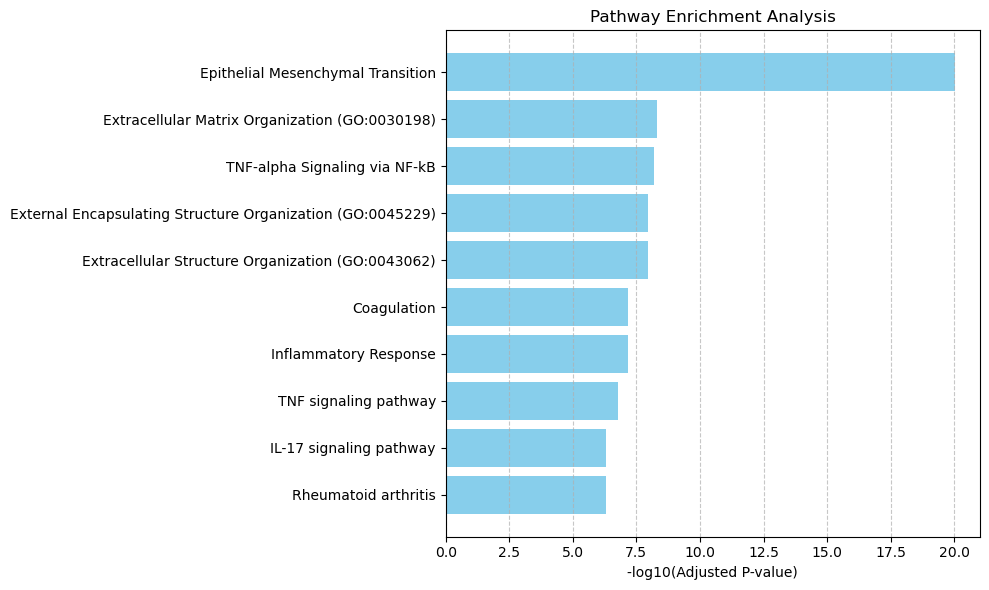

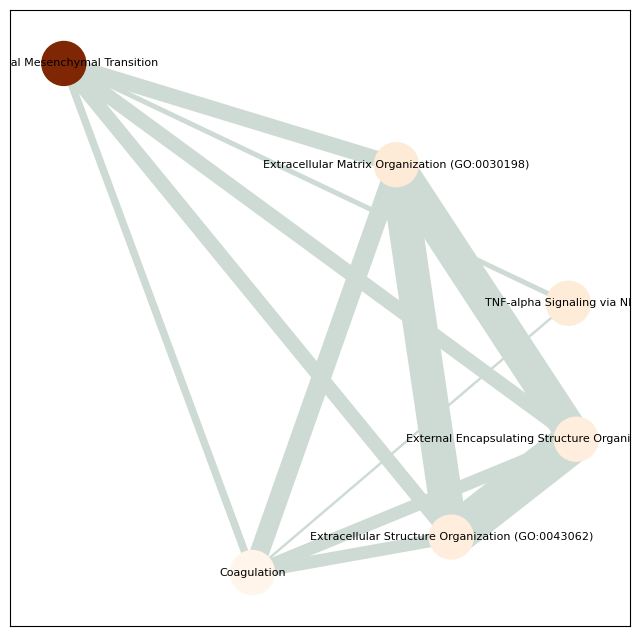

In [14]:
caf_cluster_num = '1' # Arch，
caf_cluster_num = '4' # Inflamed
caf_cluster_num = '5' # SMC-like
caf_cluster_num = '8' # Destructive

# for enrichment analysis
os.makedirs(f'{output_dir}/pathway', exist_ok = True)
from revise.analysis.bio import pathway_barplot, pathway_network_plot
for caf_cluster_num in ['1', '4', '5', '8']:
    pathway = all_pathway[all_pathway['group'] == caf_cluster_num]

    pathway_barplot(pathway, pathway_num = 10,  
                    save_file_name = f'{output_dir}/pathway/{caf_cluster_num}_barplot.pdf')
    pathway_network_plot(pathway, 
                        top_term = 6, 
                        save_file_name = f'{output_dir}/pathway/{caf_cluster_num}_network.pdf')

In [15]:
top_pathway = all_pathway.groupby('group').head(10)

top_pathway.reset_index(drop=True, inplace=True)
for caf_cluster_num in top_pathway['group'].unique():
    pathway = top_pathway[top_pathway['group'] == caf_cluster_num]
    print(caf_cluster_num, pathway['Term'].values)


1 ['Epithelial Mesenchymal Transition' 'Protein digestion and absorption'
 'ECM-receptor interaction' 'Coagulation'
 'Extracellular Matrix Organization (GO:0030198)'
 'Proteoglycans in cancer' 'Focal adhesion'
 'External Encapsulating Structure Organization (GO:0045229)'
 'Extracellular Structure Organization (GO:0043062)'
 'Skeletal System Development (GO:0001501)']
4 ['Coagulation' 'Positive Regulation of Blood Coagulation (GO:0030194)'
 'Positive Regulation of Cell Migration (GO:0030335)' 'KRAS Signaling Up'
 'Complement and coagulation cascades' 'Interferon Alpha Response'
 'Epithelial Mesenchymal Transition' 'IL-2/STAT5 Signaling'
 'Inflammatory Response'
 'Positive Regulation of Response to External Stimulus (GO:0032103)']
8 ['Epithelial Mesenchymal Transition'
 'Extracellular Matrix Organization (GO:0030198)'
 'TNF-alpha Signaling via NF-kB'
 'External Encapsulating Structure Organization (GO:0045229)'
 'Extracellular Structure Organization (GO:0043062)' 'Coagulation'
 'Inflamma

In [16]:
pathway_dict = {
    "1": ['Epithelial Mesenchymal Transition', 'Protein digestion and absorption', 'ECM-receptor interaction', 'Focal adhesion'],
    "4": ['Positive Regulation of Blood Coagulation (GO:0030194)','Complement and coagulation cascades', 'IL-2/STAT5 Signaling', 'Interferon Alpha Response'],
    "5": ['Vascular smooth muscle contraction', 'Muscle Contraction (GO:0006936)', 'Actomyosin Structure Organization (GO:0031032)', 'Regulation of actin cytoskeleton'],
    "8": ['External Encapsulating Structure Organization (GO:0045229)',
         'TNF-alpha Signaling via NF-kB', 'TNF signaling pathway', 'IL-17 signaling pathway'],
}


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['ps.useafm'] = False      

def pathway_barplot(all_pathway, pathway_dict=None, select_metric='Adjusted P-value', cmap='RdBu_r', save_file_name=None):
    df = all_pathway.copy()
    
    if select_metric == 'Adjusted P-value':
        df["plot_value"] = -np.log10(df[select_metric])
        xlabel = '-log10(Adjusted P-value)'
    else:
        df["plot_value"] = df[select_metric]
        xlabel = select_metric
    
    if pathway_dict is None:
        pathway_dict = {}
        unique_groups = df['group'].unique()
        for group in unique_groups:
            group_pathways = df[df['group'] == group]['Term'].tolist()
            pathway_dict[group] = group_pathways
    
    all_groups = list(pathway_dict.keys())
    all_pathways = []
    for pathways in pathway_dict.values():
        all_pathways.extend(pathways)
    all_pathways = list(set(all_pathways))
    
    data_matrix = {}
    for pathway in all_pathways:
        data_matrix[pathway] = {}
        for group in all_groups:
            mask = (df['Term'] == pathway) & (df['group'] == group)
            if mask.any():
                data_matrix[pathway][group] = df[mask]['plot_value'].iloc[0]
            else:
                data_matrix[pathway][group] = 0  # Use 0 if absent
    
    if isinstance(cmap, dict):
        colors_dict = cmap
        def get_color(group):
            return colors_dict.get(str(group), '#808080')  # Default gray
    else:
        colors = plt.cm.get_cmap(cmap, len(all_groups))
        def get_color(group):
            color_idx = all_groups.index(group)
            return colors(color_idx)
    
    n_subplots = len(pathway_dict)
    fig, axes = plt.subplots(1, n_subplots, figsize=(12, 8))
    if n_subplots == 1:
        axes = [axes]
    
    for idx, (group_name, pathways) in enumerate(pathway_dict.items()):
        ax = axes[idx]
        
        bar_data = []
        bar_labels = []
        pathway_positions = []
        
        current_pos = 0
        group_spacing = 0.8  
        
        pathways = list(reversed(pathways))
        
        reversed_groups = list(reversed(all_groups))
        
        for pathway_idx, pathway in enumerate(pathways):
            pathway_start_pos = current_pos
            
            for group_idx, group in enumerate(reversed_groups):
                value = data_matrix[pathway][group]
                bar_data.append({
                    'position': current_pos,
                    'value': value,
                    'group': group,
                    'pathway': pathway
                })
                bar_labels.append(group)
                current_pos += group_spacing
            
            pathway_center = pathway_start_pos + (len(all_groups) - 1) * group_spacing / 2
            pathway_positions.append((pathway_center, pathway))
            
            current_pos += 1
        
        for bar in bar_data:
            color = get_color(bar['group'])
            ax.barh(bar['position'], bar['value'], color=color, alpha=0.8, 
                   edgecolor='black', linewidth=0.5, height=0.6)
        
        ax.set_yticks([pos for pos, _ in pathway_positions])
        ax.set_yticklabels([pathway for _, pathway in pathway_positions], 
                          fontsize=10, rotation=90, ha='right')
        
        separator_positions = []
        current_sep_pos = len(all_groups) * group_spacing - group_spacing/2
        for i in range(len(pathways) - 1):
            separator_positions.append(current_sep_pos + 0.5)
            current_sep_pos += len(all_groups) * group_spacing + 1
        
        for sep_pos in separator_positions:
            ax.axhline(y=sep_pos, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(f'{group_name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        
        ax.set_xlim(left=0)
        
        ax.set_ylim(-0.5, current_pos - 0.5)
    
    if isinstance(cmap, dict):
        legend_elements = [plt.Rectangle((0,0), 1, 1, facecolor=colors_dict.get(str(group), '#808080'), alpha=0.8, 
                                       edgecolor='black', linewidth=0.5) 
                          for group in all_groups]
    else:
        legend_elements = [plt.Rectangle((0,0), 1, 1, facecolor=colors(i), alpha=0.8, 
                                       edgecolor='black', linewidth=0.5) 
                          for i in range(len(all_groups))]
    
    fig.legend(legend_elements, all_groups, 
               loc='upper center', bbox_to_anchor=(0.5, 0.05), 
               ncol=len(all_groups), frameon=True, fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  
    
    if save_file_name:
        plt.savefig(save_file_name, dpi=300, bbox_inches='tight')
        print(f"Figure saved as {save_file_name}")
    else:
        plt.show()

Figure saved as ../../output/sc_SVC_case/P2CRC_Xenium/pathway_barplot.pdf


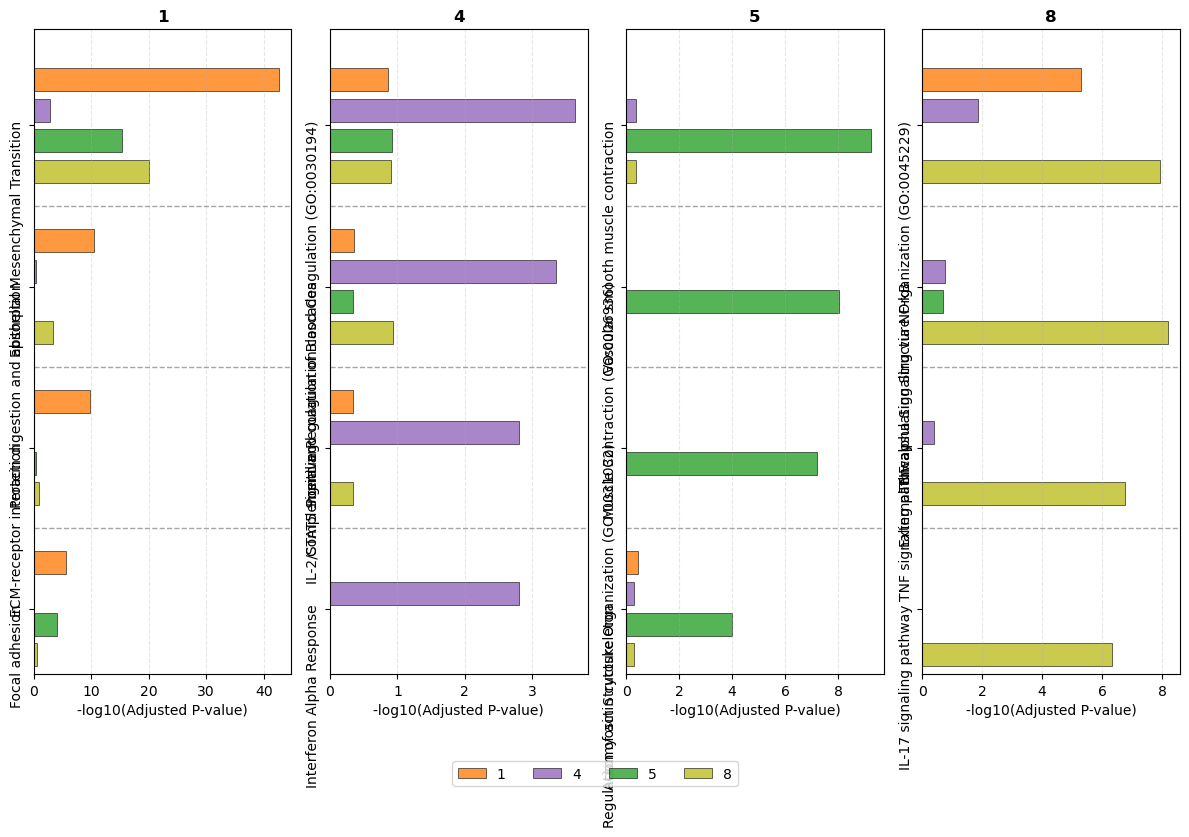

In [18]:
pathway_barplot(all_pathway[all_pathway['group'] != "6"], pathway_dict, 
                 cmap = {
                            "1": '#ff7f0e',
                            "5": '#2ca02c',
                            "4": '#9467bd',
                            "8": '#bcbd22',
                        },
                save_file_name=f'{output_dir}/pathway_barplot.pdf'
                )

## sc-SVC subtypes analysis

### CAF_8

/tmp/ipykernel_30433/1881669377.py:5: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = tumor_adata_sp.concatenate(CAF_8_adata_sp)


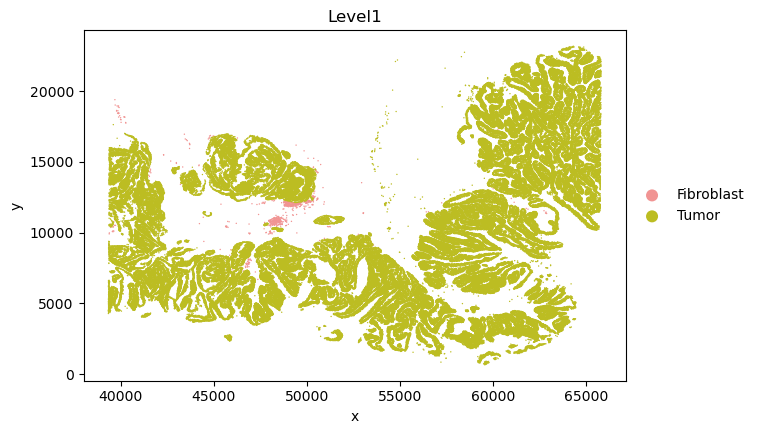

In [19]:
CAF_8_cells_names = sc_SVC_adata[sc_SVC_adata.obs['SVC_cluster'] == "8",:].obs['cell_id'].values
tumor_adata_sp = adata_sp[adata_sp.obs['Level1'] == "Tumor" ,:].copy()
CAF_8_adata_sp = adata_sp[adata_sp.obs['cell_id'].isin(CAF_8_cells_names),:].copy()
CAF_8_adata_sp.obs['Level1'] = "Fibroblast"
adata = tumor_adata_sp.concatenate(CAF_8_adata_sp)  
_apply_category_palette(adata, 'Level1', {'Tumor': '#bcbd22', 'Fibroblast': '#f19493'})

sc.pl.scatter(adata, x='x', y='y', color='Level1', size = 4)


### CAF_4

In [20]:
import scanpy as sc

sc_SVC_adata = sc.read(f"{output_dir}/sc_SVC_spatial.h5ad")
CAF_adata_sc = sc.read(f"{output_dir}/sc_SVC_expr.h5ad")


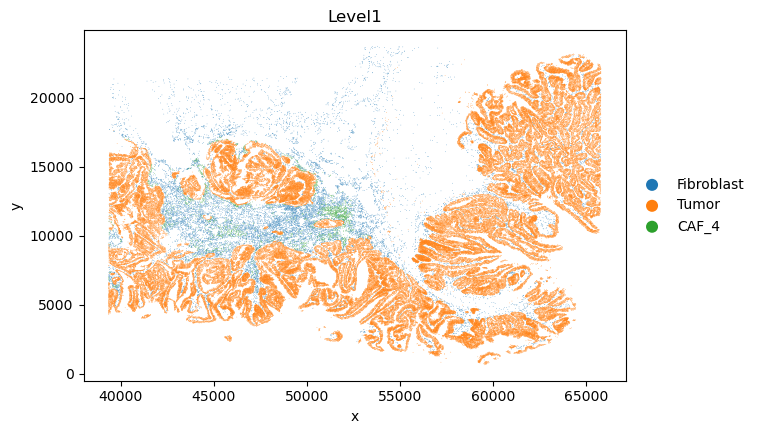

In [21]:
adata = adata_sp[adata_sp.obs['Level1'].isin(["Tumor", "Fibroblast"])].copy()
if hasattr(adata.obs['Level1'], 'cat') and "CAF_4" not in adata.obs['Level1'].cat.categories:
    adata.obs['Level1'] = adata.obs['Level1'].cat.add_categories(["CAF_4"])
caf_4_cell_ids = sc_SVC_adata.obs.loc[sc_SVC_adata.obs['SVC_cluster'] == "4", "cell_id"].values
adata.obs.loc[adata.obs['cell_id'].isin(caf_4_cell_ids), "Level1"] = "CAF_4"
sc.pl.scatter(adata, x="x", y="y", color="Level1")

In [22]:
adata.obs['Level1'].value_counts()

Level1
Tumor         145632
Fibroblast     15473
CAF_4           2136
Name: count, dtype: int64

In [23]:
import scanpy as sc
import pandas as pd

tumor_indices = adata.obs[adata.obs['Level1'] == 'Tumor'].index
fibroblast_indices = adata.obs[adata.obs['Level1'] == 'Fibroblast'].index
caf4_indices = adata.obs[adata.obs['Level1'] == 'CAF_4'].index

tumor_sampled = np.random.choice(tumor_indices, size=20000, replace=False)
fibroblast_sampled = np.random.choice(fibroblast_indices, size=3000, replace=False)
caf4_sampled = caf4_indices 

sampled_indices = np.concatenate([tumor_sampled, fibroblast_sampled, caf4_sampled])

new_adata = adata[sampled_indices, :].copy()
new_order = ['Tumor', 'Fibroblast', 'CAF_4']
current_categories = new_adata.obs['Level1'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in new_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
new_adata.obs['Level1'] = new_adata.obs['Level1'].cat.reorder_categories(ordered_categories)
_apply_category_palette(new_adata, 'Level1', {'Tumor': '#f09094', 'Fibroblast': '#d3d3d3', 'CAF_4': '#754e9e'})
new_adata.obs['Level1'].value_counts()


Level1
Tumor         20000
Fibroblast     3000
CAF_4          2136
Name: count, dtype: int64

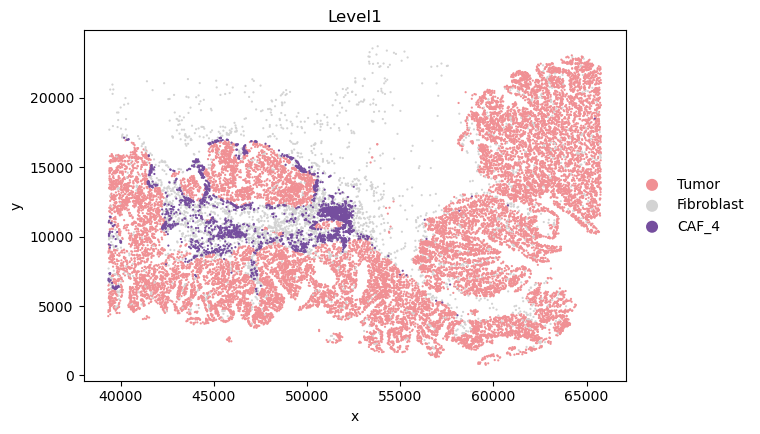

In [24]:
sc.pl.scatter(new_adata, x="x", y="y", color="Level1",size=10)

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:580: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_n_counts] = counts_per_cell


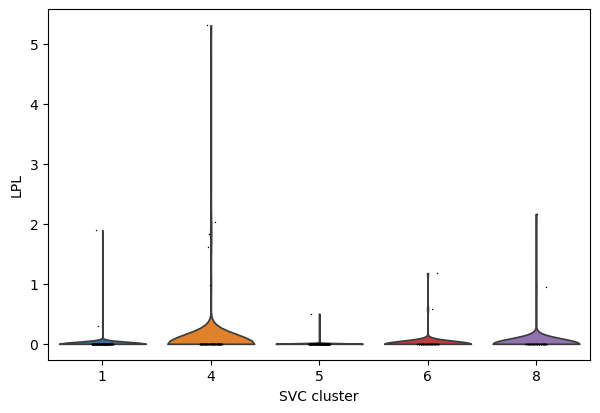

In [25]:
# compare gene LPL expression across subtypes
import scanpy as sc

sc_SVC_adata = sc.read(f"{output_dir}/sc_SVC_spatial.h5ad")
CAF_adata_sc = sc.read(f"{output_dir}/sc_SVC_expr.h5ad")


cluster_nums = ['1','4','5','6', '8']
select_adata = CAF_adata_sc[CAF_adata_sc.obs['SVC_cluster'].isin(cluster_nums)]
sc.pp.normalize_per_cell(select_adata)


sc.pl.violin(select_adata, keys="LPL", groupby="SVC_cluster", show=False)
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42     
mpl.rcParams['ps.useafm'] = False     

plt.savefig(f"{output_dir}/sc_SVC_LPL_violin.pdf", dpi=300)
plt.show()


In [26]:
def read_gmt(file_path):
    
    pathway_dict = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway_name = parts[0]
            genes = parts[2:]  # Skip the first two columns (pathway name and description)
            pathway_dict[pathway_name] = genes
    return pathway_dict

HYPOXIA_pathway = read_gmt("./pathway/HYPOXIA_related_pathways.gmt")
HYPOXIA_pathway.keys()


dict_keys(['HIF-1 signaling pathway', 'Pyruvate metabolism', 'Glycolysis / Gluconeogenesis', 'Hypoxia', 'Glycolysis', 'Hypoxia_Glycolysis'])

In [27]:
import matplotlib.colors as mcolors
import numpy as np

colors = ["#d3d3d3", "#8b0000"]  
colors = ["white","#d3d3d3", "#8b0000"]  

n_bins = 100  

# colormap
cmap = mcolors.LinearSegmentedColormap.from_list("gray_to_darkred", colors, N=n_bins)

def plot_signature(adata, signatures, score_method = "score_genes", score_name = "TLS", size = None, color_map = cmap, plot_type = "scatter", groupby='SVC_cluster', max_score = None):
    adata = adata.copy()
    valid_genes = [gene for gene in signatures if gene in adata.var_names]
    print(len(valid_genes), len(signatures))
    if score_method == "score_genes":
        sc.tl.score_genes(
                    adata,
                    gene_list=valid_genes,
                    score_name=score_name,
                    use_raw=False,  
                )
    elif score_method == "AUC":
        try:
            import omicverse as ov
        except ModuleNotFoundError as exc:
            raise ModuleNotFoundError('Install pathway dependencies with pip install \"revise-svc[pathway]\"') from exc
        ov.single.geneset_aucell(
                    adata=adata,
                    geneset_name=score_name,
                    geneset=valid_genes,
                    # AUC_threshold = 0.2
                )
        score_name = f"{score_name}_aucell"

    if max_score is not None:
        adata.obs[score_name] = np.clip(adata.obs[score_name], None, max_score)
        
    if plot_type == "scatter":
        sc.pl.scatter(adata, x="x", y="y", 
                    color=score_name, 
                    color_map=color_map,
                    size = size,
                    )
    else:
        sc.pl.violin(adata, score_name, groupby=groupby)
    return adata

Glycolysis
6 200


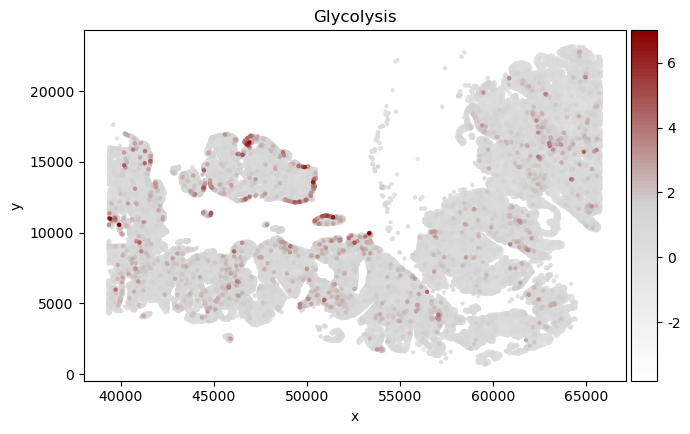

In [28]:
score_method="AUC"
score_method="score_genes"

size = 40
pathway_name = list(HYPOXIA_pathway.keys())[4]
print(pathway_name)
adata_sp_a = plot_signature(adata_sp[adata_sp.obs["Level1"] == "Tumor"], HYPOXIA_pathway[pathway_name], 
               score_method=score_method, score_name = pathway_name, 
               color_map = cmap,
               size = size,
               max_score=7)

### CAF_5

/tmp/ipykernel_30433/2681922722.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  SMC_adata.obs['SVC_cluster'] = "SMC"
/tmp/ipykernel_30433/2681922722.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  select_adata = SMC_adata.concatenate(select_adata)


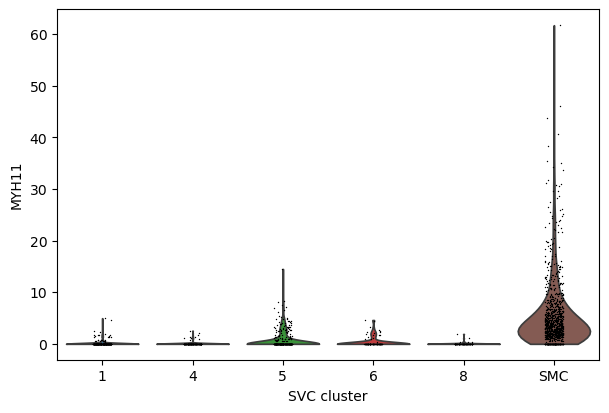

In [29]:
import scanpy as sc

SMC_adata = adata_sc[adata_sc.obs['Level1']== "SMC",:]
SMC_adata.obs['SVC_cluster'] = "SMC"
CAF_adata_sc = sc.read(f"{output_dir}/sc_SVC_expr.h5ad")


cluster_nums = ['1','4','5','6', '8']
select_adata = CAF_adata_sc[CAF_adata_sc.obs['SVC_cluster'].isin(cluster_nums)]
select_adata = SMC_adata.concatenate(select_adata)
sc.pp.normalize_per_cell(select_adata)
# sc.pp.log1p(select_adata)
sc.pl.violin(select_adata, keys="MYH11", groupby="SVC_cluster")


In [30]:
import pandas as pd
desired_order = ['SMC', '1', '4', '5', '6', '8']
select_adata.obs['SVC_cluster'] = pd.Categorical(select_adata.obs['SVC_cluster'], categories=desired_order, ordered=True)

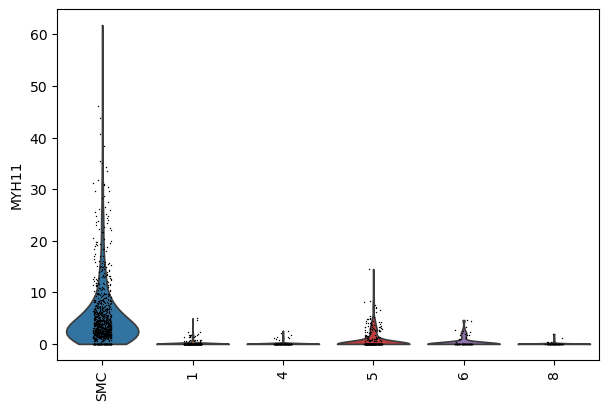

In [31]:
sc.pl.violin(select_adata, keys="MYH11", groupby="SVC_cluster", rotation=90, show=False)

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42     
mpl.rcParams['ps.useafm'] = False     

plt.savefig(f"{output_dir}/sc_SVC_MYH11_violin.pdf", dpi=300)
plt.show()


In [32]:
CAF_5_cells_names = sc_SVC_adata[sc_SVC_adata.obs['SVC_cluster'] == "5",:].obs['cell_id'].values
SMC_adata_sp = adata_sp[adata_sp.obs['Level1'] == "SMC" ,:].copy()
SMC_adata_sp.obs['SVC_cluster'] = "SMC"
CAF_5_adata_sp = adata_sp[adata_sp.obs['cell_id'].isin(CAF_5_cells_names),:].copy()
CAF_5_adata_sp.obs['Level1'] = "Fibroblast"
CAF_5_adata_sp.obs['SVC_cluster'] = "5"
adata = SMC_adata_sp.concatenate(CAF_5_adata_sp)  


/tmp/ipykernel_30433/3738435917.py:7: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = SMC_adata_sp.concatenate(CAF_5_adata_sp)


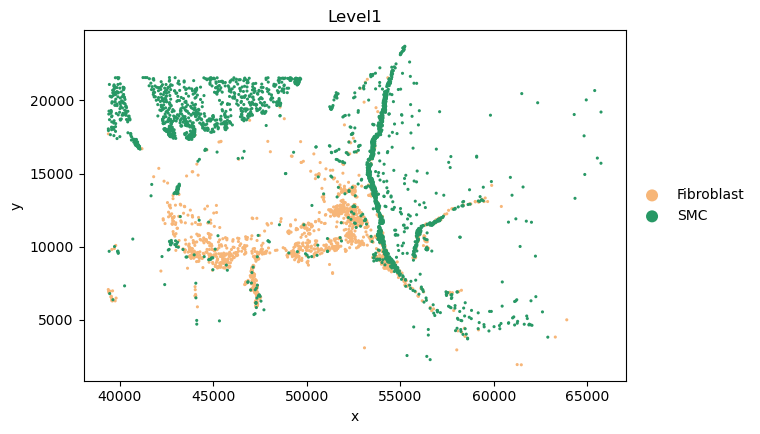

In [33]:

_apply_category_palette(adata, 'Level1', {'SMC': '#279865', 'Fibroblast': '#f7b678'})

sc.pl.scatter(adata, x='x', y='y', color='Level1', size = 20)


## Pseudotime analysis 

In [34]:
import scanpy as sc
import matplotlib.pyplot as plt
try:
    import omicverse as ov
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install trajectory dependencies with pip install \"revise-svc[trajectory]\"') from exc
ov.plot_set()

adata=ov.pp.preprocess(adata, mode='shiftlog|pearson',n_HVGs=3000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
🚫 No CUDA devices found

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.5   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

Begin robust gene identification
After filtration, 343/343 genes are kept.     Among 343 genes, 343 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['ACTA2', 'DES', 'GREM1', 'IGFBP7', 'IGHG3', 'MMP2', 'TAGLN', 'TGFBI', 'THBS1']


    finished (0:00:00)


extracting highly variable genes


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)


Time to analyze data in cpu: 7.243138074874878 seconds.
End of size normalization: shiftlog and HVGs selection pearson
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


computing PCA


    with n_comps=50


    finished (0:00:16)


In [35]:
Traj=ov.single.TrajInfer(adata,basis='X_umap',groupby='Level1',
                         use_rep='scaled|original|X_pca',n_comps=50)
Traj.set_origin_cells('SMC')
Traj.set_terminal_cells(["Fibroblast"])

In [36]:
Traj.inference(method='palantir',num_waypoints=500)

computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API

ranking genes


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


...

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API

Time for shortest paths: 0.5219881574312846 minutes
Iteratively refining the pseudotime...


Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...


Project results to all cells...


In [37]:
adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].astype(str).astype('category')
if 'SMC' not in adata.obs['SVC_cluster'].cat.categories:
    adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].cat.add_categories('SMC')
adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].fillna('SMC')


In [38]:
adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].replace('nan', 'SMC')

computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:08:46)


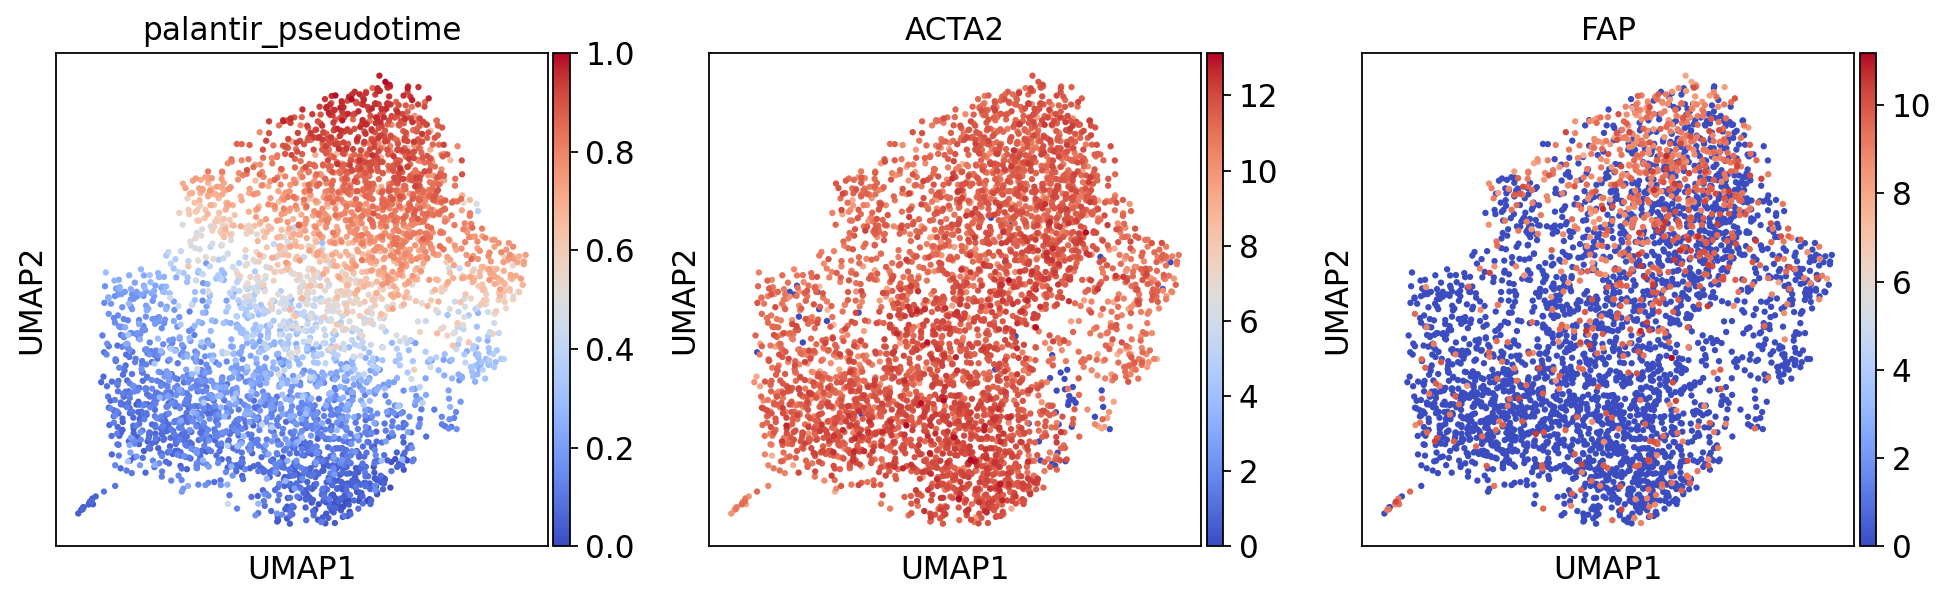

In [39]:
if 'X_umap' not in adata.obsm:
    if 'neighbors' not in adata.uns:
        sc.pp.neighbors(adata, use_rep='X_pca' if 'X_pca' in adata.obsm else None)
    sc.tl.umap(adata, random_state=0)

umap_features = ['palantir_pseudotime', 'MYH11', 'ACTA2', 'FAP', 'COL1A1']
umap_features = [feature for feature in umap_features if feature in adata.obs or feature in adata.var_names]
sc.pl.umap(adata, color=umap_features, cmap = "coolwarm")


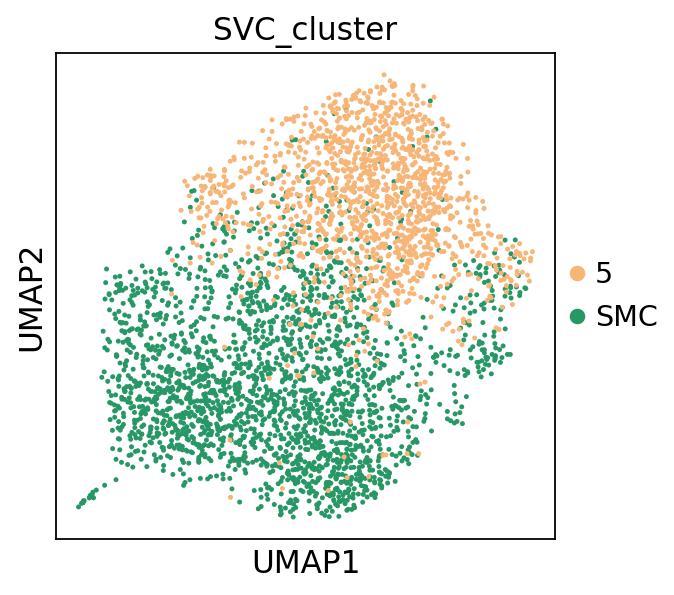

In [40]:
_apply_category_palette(adata, 'SVC_cluster', {'SMC': '#279865', '5': '#f7b678'})
sc.pl.umap(adata, color=['SVC_cluster'], size=20)
